# Visualization & simple model for $R_0$


$R_0$: "The average/expected number of secondary infections arising from a single individual during his or her entire infectious period, in a population of susceptibles" (Heffernan et al, 2005)

Goal: $R_0$ has not been reliably estimated for E. coli. With the available data set and likelihood-free inference tools, could we find this via simulation?


States:
- $C_s$: colonized by a specific E. coli strain of interest $s$.
- $I_s$: infected by e.coli (strain of interest or any?)
- $S$: susceptible to colonization by strain $s$. In other words, colonized by any other strain than $s$ or not colonized at all.

Parameters:
- $C_s$ -> S: Colonization by strain $s$ is "cleared", i.e, actually dissapears (caused for example by usage of antibiotics), or becomes replaced by another strain.
- $C_s$ -> I: Colonization develops into an infection
- (I -> $C_s$: Infected patient goes back to colonized state by strain $s$. Assumed to be neglible?)
- S -> $C_s$: susceptible individual is colonized by strain $s$
- I -> S: Infected patient goes back to susceptible state (maybe use of antibiotics clears the colonization? or the strain that infected the patient in the first place is not "strong enough" -> clearance.)

There should be a rate parameter for each of these transitions. They are then simulated using likelihood-free inference, more specifically the ELFI tool. (Lintusaari et al, 2018)

Through simulations, we can find the set of parameters that most closely matches the data. The inferred parameters can be used to determine $R_0$ (how?)

Simplifications:
- Stratification by age groups: at first, no stratification, just see the evolvement of the entire population.
- One-vs-all approach to strains/CCs/STs

Simplifications can be expanded on later.

Future model configurations:
- Stratification by age group, complex strain dynamics
- IBM/ABM with one-vs-all strains. 
- Endgame: ABM with complex strain dynamics (c++?)



## Practicalities
To install to the correct python version, use `python3 -m pip install seaborn` otherwise will use some old Python v2. Do this via jupyter terminal. Also restart jupyter after installing packages, fixed "ModuleNotFound" error for me :)

Required packages (TODO: create anaconda environment ASAP)
- xlrd (to read excel files) DEPRECATED support for xlsx files, use `openpyxl` instead.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Part 1: Preprocessing

Good to know:
- [add something]

In [5]:
# load the data

df = pd.read_excel("data/mmc2.xlsx", engine = 'openpyxl')

In [6]:
# take a look
print(df.shape)
print(df.columns)
df.head()

(3254, 63)
Index(['lane', 'Run accession', 'popPUNK_cluster', 'ST', 'CC131_clades',
       'Duplicate', 'year', 'Lab', 'Hospital name',
       'Regional health authority', 'Clermont_Phylotype', 'FimH', 'folP',
       'gyrA', 'parC', 'gyrA_parC', 'parE', 'pmrB', 'blaTEM1', 'strB', 'sul2',
       'strA', 'sul1', 'dfrA', 'tetA', 'tetB', 'aadA', 'mphA', 'dfrA1',
       'aac3_Iia', 'catA1', 'dfrA5', 'CTX-M-type', 'CTX-M', 'dfrA14', 'blaOXA',
       'aph3', 'catB3', 'acc', 'blaSHV', 'dfrA12', 'sul3', 'cmlA1', 'dfrA8',
       'C_mefB', 'QnrS1', 'floR', 'Ampicillin_SIR', 'Aztreonam_SIR',
       'Cefotaxim_SIR', 'Ceftazidim_SIR', 'Cefuroxim_SIR', 'Ciprofloxacin_SIR',
       'Ciprofloxacin_NS', 'ESBL', 'Gentamicin_SIR', 'Meropenem_SIR',
       'Nalidixin_SIR', 'Piperacillin_tazobactam_SIR', 'Sulfa_SIR',
       'Tigecyklin_SIR', 'Tobramycin_SIR', 'Trimetoprim_sulfa_SIR'],
      dtype='object')


,lane,Run accession,popPUNK_cluster,ST,CC131_clades,Duplicate,year,Lab,Hospital name,Regional health authority,...,Ciprofloxacin_NS,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Sulfa_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR
0,30134_6#100,ERR4034085,1,73,NaN,NaN,2004,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,NaN,NaN,S
1,30134_6#101,ERR4034086,8,127,NaN,NaN,2015,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,I,NaN,S,NaN,S
2,30134_6#103,ERR4034087,3,69,NaN,NaN,2013,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,S,NaN,R
3,30134_6#104,ERR4034088,1,73,NaN,NaN,2005,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,NaN,NaN,S
4,30134_6#105,ERR4034089,5,537,NaN,NaN,2011,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,S,-,S,S,NaN,S,NaN,S,NaN,S


In [7]:
# describe
df.describe(include=['object']) # use 'object' for categorical data

,lane,Run accession,CC131_clades,Duplicate,Lab,Hospital name,Regional health authority,Clermont_Phylotype,FimH,folP,...,Ciprofloxacin_SIR,Ciprofloxacin_NS,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR
count,3254,3254,278,3,3254,3254,3254,3254,3254,2,...,3253,3254,2075,3254,3085,798,3254,2501,196,3254
unique,3254,3254,6,2,15,15,4,11,263,1,...,3,2,4,3,3,2,3,4,3,3
top,30134_6#100,ERR4034085,A,Duplicated in plate,Haukeland,Haukeland universitetssykehus,Helse Sør-Øst,B2,fimH27,folP.P64S,...,S,S,-,S,S,S,S,S,S,S
freq,1,1,75,2,399,399,1625,2180,521,2,...,2876,2876,1263,2992,3081,705,3109,2480,188,2401


## Part 2: Visualization

Figure 1: Barplot of the counts of STs (10 most common)

Figure 2: Barplot of the counts of STs over time


How cool would that be to:
- Create an interactive network visualization of the counts of specific STs etc in specific hospitals! And then you could cycle through the years.

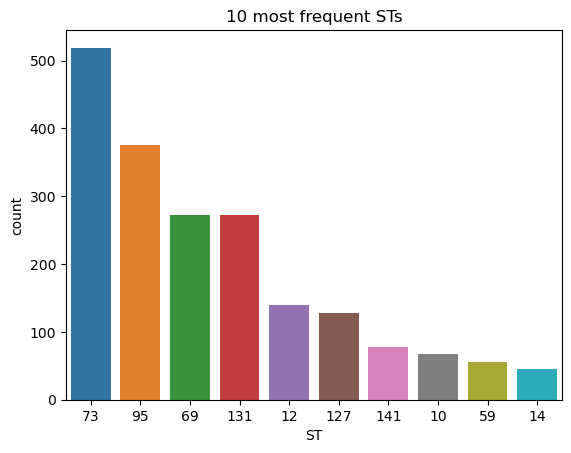

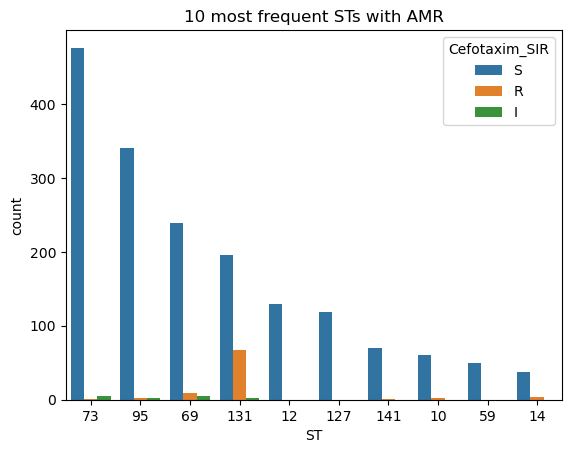

In [8]:
feat = "ST"
N = 10

# ten most frequent STs
sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index)
plt.title(str(N) + " most frequent " + feat + "s")
plt.show()

amr = 'Cefotaxim_SIR'
sns.countplot(data = df, x = feat, order = pd.value_counts(df[feat]).iloc[:N].index, hue = amr)
plt.title(str(N) + " most frequent " + feat + "s with AMR")
plt.show()

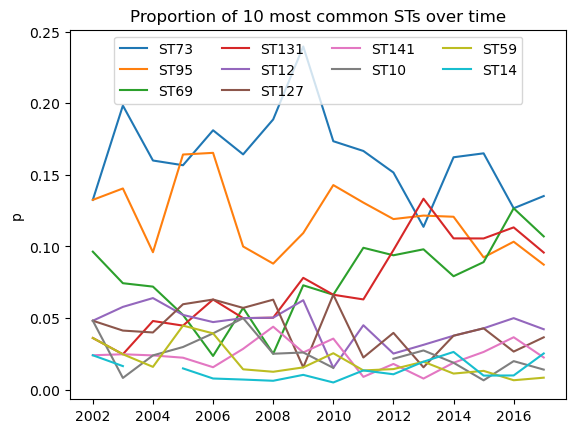

In [9]:
# plot the ten most common STs over time
st = 131
df_vis = pd.value_counts(df.loc[df['ST'] == st]["year"])/pd.value_counts(df["year"])
for st in pd.value_counts(df["ST"]).iloc[:N].index:
    df_vis = pd.value_counts(df.loc[df['ST'] == st]["year"]).sort_index()/pd.value_counts(df["year"]).sort_index()
    plt.plot(df_vis.index, df_vis, label = "ST" + str(st))
plt.legend(loc="upper center", ncol = 4)
plt.ylabel("p")
plt.title("Proportion of " + str(N) + " most common STs over time")
plt.show()

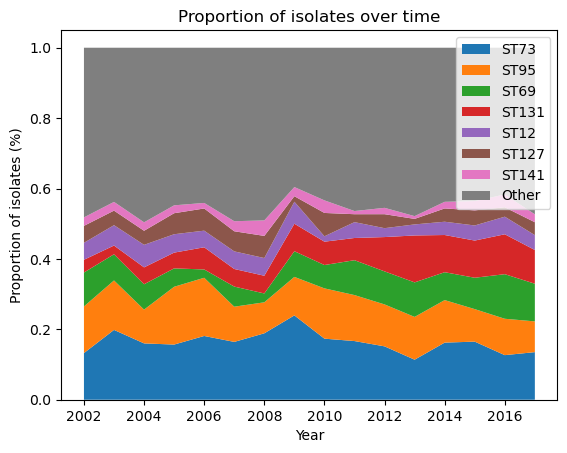

In [10]:
# the stackplot recreation
y = []
x = pd.value_counts(df["year"]).sort_index().index
N = 7
for st in pd.value_counts(df["ST"]).iloc[:N].index:
    y.append(list(pd.value_counts(df.loc[df['ST'] == st]["year"]).sort_index()/pd.value_counts(df["year"]).sort_index()))

# todo: add an aggregate column that has all the other STs stacked to one line
other_sts = list(pd.value_counts(df["ST"]).iloc[N:len(np.unique(df["ST"]))].index) # the other STs
y_other = list(pd.value_counts(df.loc[df['ST'].isin(other_sts)]["year"])/pd.value_counts(df["year"]).sort_index())
# labels
labs = ["ST" + str(i) for i in list(pd.value_counts(df["ST"]).iloc[:N].index)]
labs.append("Other")

# combine
y.append(y_other)

plt.stackplot(x,y,labels=labs)
plt.legend(loc='upper right')
plt.title("Proportion of isolates over time")
plt.ylabel("Proportion of isolates (%)")
plt.xlabel("Year")
plt.show()



TODO: proportion barplot t and t+1, one-vs-all approach. Basically rate params from data. Probably requires quite heavy reshaping of the data.

- Problem: how to infer the porportion of colonized, susceptible and infected, when the data contains colonized cases (or actually infected?) Solution: by comparing 1 ST to all other ST:s. Colonized by some other st = not colonized at all :)

[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
             p     t
2002  0.036145  2002
2003  0.024793  2003
2004  0.048000  2004
2005  0.044776  2005
2006  0.062992  2006
(16, 2)
RangeIndex(start=0, stop=3254, step=1)
Index(['p', 't'], dtype='object')


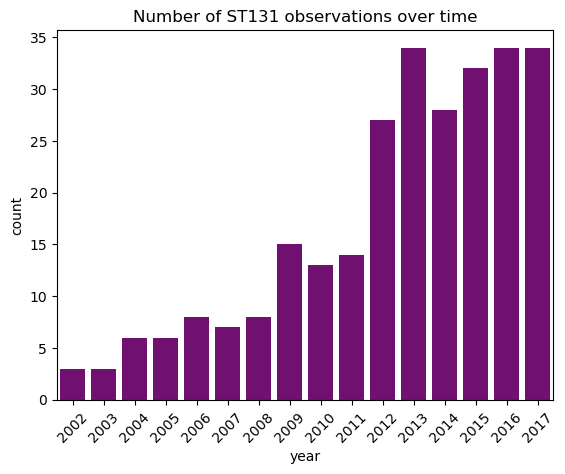

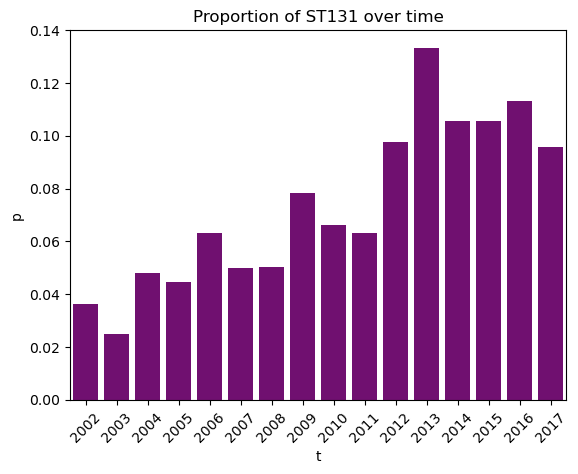

In [11]:
# TODO

df.head(5)


st = 131

# plot the proportion of ST31 over each year. Barplot with CIs. Or boxplot?

# step 1: calculate the prop of the st of interest for one year
year = 2004

df_vis = pd.DataFrame(pd.value_counts(df.loc[df['ST'] == st]["year"])/pd.value_counts(df["year"])).rename(columns = {"year": "p"}) # same as the line plot


years = [row for row in df_vis.index]
df_vis["t"] = years
print(years)

print(df_vis.head(5))
print(df_vis.shape)
print(df.index)
print(df_vis.columns)

# one vs all: number of observations
sns.countplot(data = df.loc[df['ST'] == st], x = "year", color = "purple")
plt.title("Number of ST" + str(st) + " observations over time")
plt.xticks(rotation = 45)
plt.show()

# one vs all: proportion of observations
sns.barplot(data = df_vis, x = "t", y = "p", color = "purple")
plt.title("Proportion of ST" + str(st) + " over time")
plt.xticks(rotation = 45)
plt.show()


In [ ]:
# Event matrix type visualisation: ST-ST matrix.
# Paitsi että eihän tämä ole järkevä, koska tässä aina yhdeltä individualilta
# saadaan yksi näyte. TODO: replikoi vauvadatalle.

# Part 3: ELFI

ST131 vs all. So baseline/defnition of a susceptible population = no ST131 colonization.

[ELFI documentation](https://elfi.readthedocs.io/en/latest/)

Components in ELFI graph
- TODO: Simulators, summaries etc.

Local installation:
- `pip3 install elfi`

### Questions
- What is the subject indicator here? Is there only one sample per subject?
- On what level are we modelling, subject or just observations? How to define "missingness" of some ST colonization if we don't have time series data from a single subject?

In [12]:
import elfi

warning in stationary: failed to import cython module: falling back to numpy
warning in coregionalize: failed to import cython module: falling back to numpy
warning in choleskies: failed to import cython module: falling back to numpy


### One vs all model

- Colonization explored on the level of ST. Colonzied, if there was a specific ST found. If not, not colonized.

$y$: colonized or not, 0 = no, 1 = yes


**Model**
- Priors?
- The model itself (some ODE? or just multiply by some rate parameter the number of colonized/suseceptible cases?)

In [151]:
[1]*10

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [13]:
# First, some reshaping of data: add y, whether an observation is colonized by the ST of interest or not

# initialize y with zeros
y = np.zeros(df.shape[0])
df["y"] = y
print(len(y))

# choose st of interest
st = 131

# update y
df.loc[df['ST'] == st] # 272 cases

3254


,lane,Run accession,popPUNK_cluster,ST,CC131_clades,Duplicate,year,Lab,Hospital name,Regional health authority,...,ESBL,Gentamicin_SIR,Meropenem_SIR,Nalidixin_SIR,Piperacillin_tazobactam_SIR,Sulfa_SIR,Tigecyklin_SIR,Tobramycin_SIR,Trimetoprim_sulfa_SIR,y
5,30134_6#107,ERR4034090,4,131,A,NaN,2014,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,+,R,S,NaN,S,NaN,S,NaN,R,0.0
12,30134_6#115,ERR4034096,4,131,B,NaN,2012,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,I,S,NaN,S,NaN,S,NaN,R,0.0
15,30134_6#119,ERR4034099,4,131,C1,NaN,2013,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,S,S,NaN,S,NaN,S,NaN,S,0.0
16,30134_6#120,ERR4034100,4,131,A,NaN,2011,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,S,S,NaN,S,NaN,S,NaN,S,0.0
35,30134_6#145,ERR4034119,4,131,C1,Triplicate from patient same ST,2014,Tromsø,Universitetssykehuset Nord-Norge,Helse Nord,...,-,S,S,NaN,S,NaN,S,NaN,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3210,31663_7#288,ERR4037496,4,131,C2,NaN,2015,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,NaN,S,NaN,NaN,NaN,S,0.0
3236,31663_7#381,ERR4037520,4,131,C1,NaN,2015,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,S,S,NaN,S,S,S,0.0
3242,31663_7#59,ERR4037439,4,131,C2,NaN,2014,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,NaN,S,NaN,S,NaN,R,0.0
3249,31663_7#85,ERR4037446,4,131,A,NaN,2014,Ahus,Akershus universitetssykehus,Helse Sør-Øst,...,-,S,S,NaN,S,NaN,NaN,NaN,S,0.0


# SIR model with least squares estimation

- Step 1: Create a simulator of your own DONE
- Step 2: Do some inference on the simulated data DONE simple least squares

In [218]:
# Building a simple SIR model using ELFI


def dS(S, I, t, beta, N):

    return -beta*S[t]*I[t]/N[t]

def dI(I, S, t, gamma, N):
    
    return beta*S[t]*I[t]/N[t] - gamma*I[t]

def dR(I, t, gamma):
    
    return gamma*I[t]


def SIR(I0, R0, S0, N, T, beta, gamma):
    
    S = [S0]
    I = [I0]
    R = [R0]
    N = [N]*(len(T) - 1) #*(len(T)-1) # Assume a fixed population size over time.
    
    for t in T[0:(len(T)-1)]:
        
        # Update SIR model
        I.append(I[t] + dI(I, S, t, gamma, N))
        R.append(R[t] + dR(I, t, gamma))
        S.append(S[t] + dS(S, I, t, beta, N))
        
    return S, I, R


# So I want to model how S, I, R develop with different parameters gamma and beta.

#dS(S=[100], I = [2], t = 0, beta = 0.2, N = [100]) # negative. Works I guess.

In [219]:

T = [i for i in range(0,199)] # Simulate over 1000 timepoints
y = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = 0.5, gamma = 0.2)

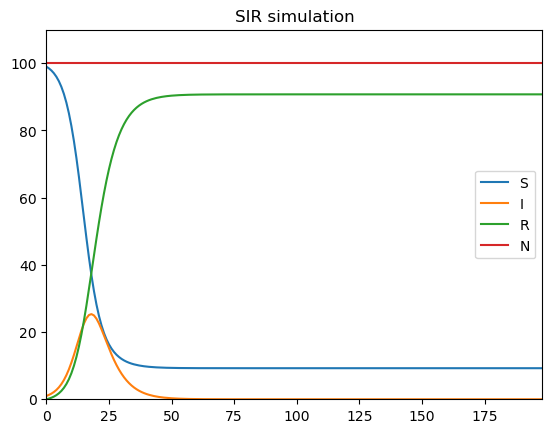

In [220]:
N = [100]*len(T)
plt.axis([0, max(T), 0, max(N) + 10])

S = y[0]
I = y[1]
R = y[2]

plt.plot(T, S)
plt.plot(T, I)
plt.plot(T, R)
plt.plot(T, N)
plt.title("SIR simulation")
plt.legend(["S", "I", "R", "N"])
plt.show()

In [221]:
np.array([1,2,3]) - np.array([1,0.2,4])

array([ 0. ,  1.8, -1. ])

In [222]:
T = [i for i in range(0,100)]
SIR_obs = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = 0.5, gamma = 0.2)
SIR_hat = SIR(I0 = 1, R0 = 0, S0 = 99, N = 100, T=T, beta = 0.1, gamma = 0.2)

In [278]:
# Based on simulated data, what is the value of beta and gamma?

# Basic least squares loss first

def least_squares_estimator(SIR_obs, N, T = 100, plot_loss = False):
    # Simple least squares estimator for calculating beta of a SIR model from data.
    # Assume same initial values as data
    
    I0 = np.ceil(min(SIR_obs[1]))
    R0 = np.ceil(min(SIR_obs[2]))
    S0 = np.ceil(max(SIR_obs[0]))
    
    print("Initial values:", I0, R0, S0)

    T = [i for i in range(0,T)]
    
    S_obs = SIR_obs[0]
    I_obs = SIR_obs[1]
    R_obs = SIR_obs[2]


    gamma = 0.2

    losses = []
    betas = []

    p_test = 0.4 # How much of the observed/simulated distribution is used to calculate the loss
    n_test = int(len(I_obs)*p_test)

    for b in np.arange(0, 2, 0.01): # Iterate over a range of potential values of beta

        new_SIR = SIR(I0, R0, S0, N, T, beta = b, gamma = gamma) # Simulated dataset at the value of beta

        # Compute loss on the number of infected patient
        loss_I = np.sum((np.array(new_SIR[1][0:n_test]) - np.array(I_obs[0:n_test]))**2)
        #loss_S = np.sum((np.array(new_SIR[0]) - np.array(S_obs))**2)
        losses.append(loss_I)
        betas.append(b)


    print("Smallest loss:", np.min(losses))
    print("Achieved at beta =", betas[losses.index(np.min(losses))])
    
    if plot_loss:
        plt.axis([0, max(betas), 0, np.median(losses)])
        plt.plot(betas, losses)
        plt.title("SSE loss vs beta")
        plt.xlabel("beta")
        plt.ylabel("SSE")
        plt.show()
        
        
    #return losses, betas
    

Initial values: 1.0 0.0 99.0
Smallest loss: 0.0
Achieved at beta = 0.5


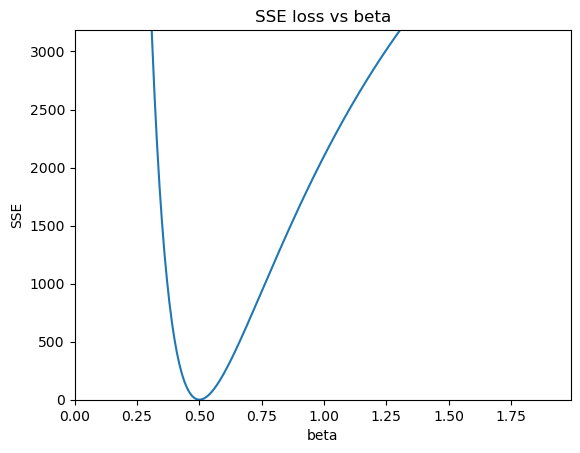

In [279]:
least_squares_estimator(SIR_obs, 100, plot_loss = True)

# SIR model with ELFI

In [282]:
import scipy

In [284]:
# Define priors
beta = elfi.Prior(scipy.stats.norm, 0, 5) # some random normal prior for beta
gamma = elfi.Prior(scipy.stats.norm, 0, 10)

In [ ]:
# a node is defined by giving a distribution from scipy.stats together with any arguments (here 0 and 2)
t1 = elfi.Prior(scipy.stats.uniform, 0, 2)

# ELFI also supports giving the scipy.stats distributions as strings
t2 = elfi.Prior('uniform', 0, 2)